<a href="https://colab.research.google.com/github/IvanLuetic/racunalni-vid/blob/main/RacunalniVid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 8.7 MB/s eta 0:00:00


In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/access_token', 'w') as f:
    f.write('')

!chmod 600 /root/.kaggle/access_token

In [ ]:
!kaggle datasets download -d benjaminkz/places365 -p /content/places365_raw --unzip

Dataset URL: https://www.kaggle.com/datasets/benjaminkz/places365
License(s): CC0-1.0
100% 23.5G/23.5G [04:47<00:00, 88.0MB/s]



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil, os
shutil.unpack_archive('/content/drive/MyDrive/places365_subset.zip', '/content/places365_subset')
print( len(os.listdir('/content/places365_subset/train')), 'classes')

15 classes


In [ ]:
import os, shutil, random

SRC_TRAIN = '/content/places365_raw/train'
SRC_VAL = '/content/places365_raw/val'
DST = '/content/places365_subset'
N_TRAIN, N_VAL = 300, 60

selected_classes = [
    'beach', 'forest-broadleaf', 'kitchen', 'bedroom',
    'stadium-baseball', 'mountain', 'office', 'street',
    'bridge', 'desert-sand', 'restaurant_patio', 'sky',
    'raceway', 'boardwalk', 'islet'
]

random.seed(42)

for cls in selected_classes:
    train_src_folder = f'{SRC_TRAIN}/{cls}'
    train_imgs = os.listdir(train_src_folder)
    random.shuffle(train_imgs)
    train_dst_folder = f'{DST}/train/{cls}'
    os.makedirs(train_dst_folder, exist_ok=True)
    for f in train_imgs[:N_TRAIN]:
        shutil.copy(f'{train_src_folder}/{f}', f'{train_dst_folder}/{f}')

    val_src_folder = f'{SRC_VAL}/{cls}'
    val_imgs = os.listdir(val_src_folder)
    random.shuffle(val_imgs)
    val_dst_folder = f'{DST}/val/{cls}'
    os.makedirs(val_dst_folder, exist_ok=True)
    for f in val_imgs[:N_VAL]:
        shutil.copy(f'{val_src_folder}/{f}', f'{val_dst_folder}/{f}')

    print(f'{cls}: {len(os.listdir(train_dst_folder))} train, {len(os.listdir(val_dst_folder))} val')



In [ ]:
import shutil

shutil.make_archive('/content/places365_subset', 'zip', '/content/places365_subset')
shutil.copy('/content/places365_subset.zip', '/content/drive/MyDrive/places365_subset.zip')
print('Saved to Drive.')

In [ ]:
CONFIG = {
    'data_root': '/content/places365_subset',
    'batch_size': 32,
    'num_epochs': 15,
    'learning_rate': 1e-3,
    'img_size': 224,
    'num_workers': 2,
    'save_dir': '/content/drive/MyDrive/places365_results',
}

import os
import torch

os.makedirs(CONFIG['save_dir'], exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [ ]:
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(CONFIG['img_size'], scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
from torchvision import datasets

train_dir = os.path.join(CONFIG['data_root'], 'train')
val_dir = os.path.join(CONFIG['data_root'], 'val')

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print(f'Broj klasa: {num_classes}')
print(f'Train uzoraka: {len(train_dataset)}')
print(f'Val uzoraka: {len(val_dataset)}')

Broj klasa: 15
Train uzoraka: 4500
Val uzoraka: 900


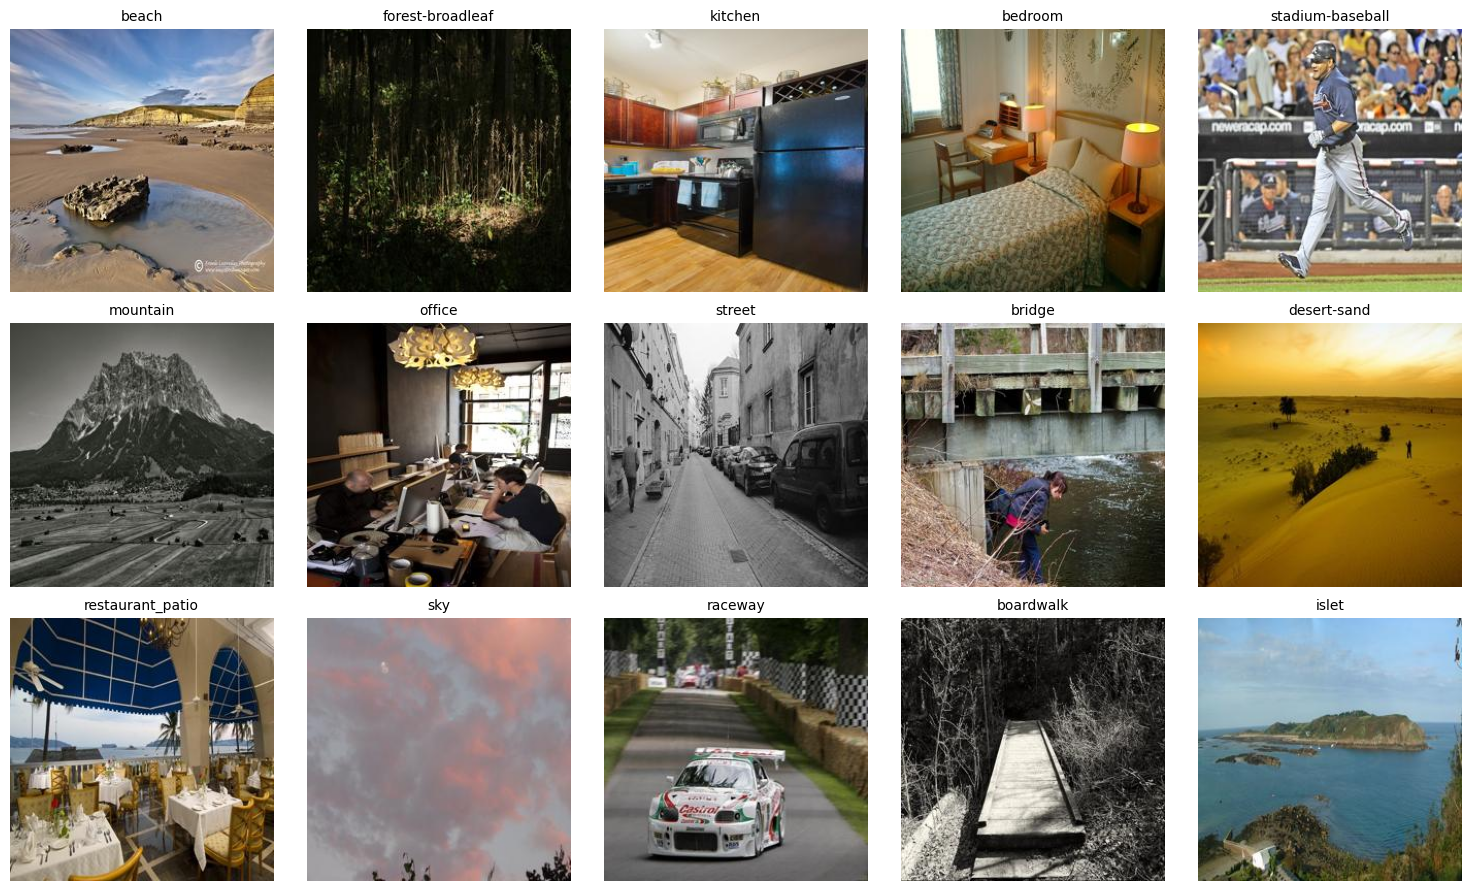

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for ax, cls in zip(axes, selected_classes):
    folder = f'/content/places365_subset/train/{cls}'
    img_path = os.path.join(folder, os.listdir(folder)[0])
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(cls, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                          shuffle=True, num_workers=CONFIG['num_workers'], pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'],
                        shuffle=False, num_workers=CONFIG['num_workers'], pin_memory=True)

In [ ]:
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

    def forward(self, x):
        return self.block(x)


class CustomCNN(nn.Module):
    def __init__(self, num_classes, in_channels=3):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(in_channels, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

In [ ]:
import torch.optim as optim
from tqdm import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Train', leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, desc='Val', leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_preds, all_labels

In [ ]:
import copy
import json

def train_model(model, model_name, train_loader, val_loader, device,
                 num_epochs=CONFIG['num_epochs'], lr=CONFIG['learning_rate']):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    ckpt_path = os.path.join(CONFIG['save_dir'], f'{model_name}_checkpoint.pth')
    best_path = os.path.join(CONFIG['save_dir'], f'{model_name}_best.pth')
    hist_path = os.path.join(CONFIG['save_dir'], f'{model_name}_history.json')

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_acc = 0.0
    best_state = None
    start_epoch = 0

    if os.path.exists(ckpt_path):
        print(f'[{model_name}] Found existing checkpoint')
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        history = ckpt['history']
        best_acc = ckpt['best_acc']
        best_state = ckpt['best_state']
        start_epoch = ckpt['epoch'] + 1
        print(f'[{model_name}] Resuming from epoch {start_epoch}/{num_epochs}')

    for epoch in range(start_epoch, num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"[{model_name}] Epoch {epoch+1}/{num_epochs} "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': history,
            'best_acc': best_acc,
            'best_state': best_state,
        }, ckpt_path)

        with open(hist_path, 'w') as f:
            json.dump(history, f)

    model.load_state_dict(best_state)
    torch.save({'model_state_dict': best_state, 'val_acc': best_acc}, best_path)

    return model, history

In [ ]:
custom_model = CustomCNN(num_classes=num_classes)
custom_model, custom_history = train_model(custom_model, 'custom_cnn', train_loader, val_loader, device)

[custom_cnn] Epoch 1/15 train_loss=2.2980 train_acc=0.2222 val_loss=2.0772 val_acc=0.2833


[custom_cnn] Epoch 2/15 train_loss=2.0242 train_acc=0.3058 val_loss=1.8478 val_acc=0.3689


[custom_cnn] Epoch 3/15 train_loss=1.9123 train_acc=0.3362 val_loss=1.7648 val_acc=0.4044


[custom_cnn] Epoch 4/15 train_loss=1.8249 train_acc=0.3696 val_loss=1.7319 val_acc=0.4022


[custom_cnn] Epoch 5/15 train_loss=1.7845 train_acc=0.3769 val_loss=1.7362 val_acc=0.3867


...

[custom_cnn] Epoch 11/15 train_loss=1.5355 train_acc=0.4716 val_loss=1.3927 val_acc=0.5222


[custom_cnn] Epoch 12/15 train_loss=1.4989 train_acc=0.4749 val_loss=1.4068 val_acc=0.5211


[custom_cnn] Epoch 13/15 train_loss=1.5016 train_acc=0.4811 val_loss=1.3726 val_acc=0.5322


[custom_cnn] Epoch 14/15 train_loss=1.4695 train_acc=0.4833 val_loss=1.3431 val_acc=0.5456


[custom_cnn] Epoch 15/15 train_loss=1.4670 train_acc=0.4989 val_loss=1.3438 val_acc=0.5367


In [ ]:
print('Best val accuracy:', max(custom_history['val_acc']))
print('\nFull history:')
for i, (tl, ta, vl, va) in enumerate(zip(
        custom_history['train_loss'], custom_history['train_acc'],
        custom_history['val_loss'], custom_history['val_acc'])):
    print(f"Epoch {i+1}: train_loss={tl:.4f} train_acc={ta:.4f} val_loss={vl:.4f} val_acc={va:.4f}")

Best val accuracy: 0.5455555555555556

Full history:
Epoch 1: train_loss=2.2980 train_acc=0.2222 val_loss=2.0772 val_acc=0.2833
Epoch 2: train_loss=2.0242 train_acc=0.3058 val_loss=1.8478 val_acc=0.3689
Epoch 3: train_loss=1.9123 train_acc=0.3362 val_loss=1.7648 val_acc=0.4044
Epoch 4: train_loss=1.8249 train_acc=0.3696 val_loss=1.7319 val_acc=0.4022
Epoch 5: train_loss=1.7845 train_acc=0.3769 val_loss=1.7362 val_acc=0.3867
Epoch 6: train_loss=1.7264 train_acc=0.3976 val_loss=1.6426 val_acc=0.4378
Epoch 7: train_loss=1.6954 train_acc=0.4080 val_loss=1.5460 val_acc=0.4756
Epoch 8: train_loss=1.6540 train_acc=0.4204 val_loss=1.6258 val_acc=0.4489
Epoch 9: train_loss=1.6116 train_acc=0.4389 val_loss=1.4956 val_acc=0.4878
Epoch 10: train_loss=1.5598 train_acc=0.4598 val_loss=1.4366 val_acc=0.5044
Epoch 11: train_loss=1.5355 train_acc=0.4716 val_loss=1.3927 val_acc=0.5222
Epoch 12: train_loss=1.4989 train_acc=0.4749 val_loss=1.4068 val_acc=0.5211
Epoch 13: train_loss=1.5016 train_acc=0.4811

In [ ]:
from torchvision import models

def build_pretrained_model(arch, num_classes, freeze_backbone=False):
    if arch == 'vgg16':
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in model.features.parameters():
                param.requires_grad = False
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_features, num_classes)

    elif arch == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        if freeze_backbone:
            for name, param in model.named_parameters():
                if not name.startswith('fc'):
                    param.requires_grad = False
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif arch == 'efficientnet':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in model.features.parameters():
                param.requires_grad = False
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f'Unknown arch: {arch}')

    return model

In [ ]:


vgg16_model = build_pretrained_model('vgg16', num_classes, freeze_backbone=True)
vgg16_model, vgg16_history = train_model(
    vgg16_model, 'vgg16_frozen_lowlr',
    train_loader, val_loader, device,
    num_epochs=10, lr=1e-4
)

[vgg16_frozen_lowlr] Found existing checkpoint
[vgg16_frozen_lowlr] Resuming from epoch 15/10


In [ ]:
print('Best val accuracy:', max(vgg16_history['val_acc']) if 'vgg16_history' in dir() else 'not trained yet')

Best val accuracy: 0.8344444444444444


In [ ]:
resnet_model = build_pretrained_model('resnet50', num_classes, freeze_backbone=True)
resnet_model, resnet_history = train_model(
    resnet_model, 'resnet50_frozen',
    train_loader, val_loader, device,
    num_epochs=10, lr=1e-4
)

[resnet50_frozen] Found existing checkpoint
[resnet50_frozen] Resuming from epoch 10/10


In [ ]:
efficientnet_model = build_pretrained_model('efficientnet', num_classes, freeze_backbone=True)
efficientnet_model, efficientnet_history = train_model(
    efficientnet_model, 'efficientnet_frozen',
    train_loader, val_loader, device,
    num_epochs=10, lr=1e-4
)

[efficientnet_frozen] Found existing checkpoint
[efficientnet_frozen] Resuming from epoch 10/10


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

def full_evaluation(model, model_name, val_loader, device, class_names):
    criterion = nn.CrossEntropyLoss()
    _, val_acc, preds, labels = evaluate(model, val_loader, criterion, device)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average='macro')
    f1_weighted = f1_score(labels, preds, average='weighted')
    cm = confusion_matrix(labels, preds)

    print(f'--- {model_name} ---')
    print(f'Accuracy: {acc:.4f}')
    print(f'F1 (macro): {f1_macro:.4f}')
    print(f'F1 (weighted): {f1_weighted:.4f}')
    print(classification_report(labels, preds, target_names=class_names, zero_division=0))

    return {
        'model_name': model_name,
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'confusion_matrix': cm,
    }

In [ ]:
models_to_eval = {
    'custom_cnn': custom_model,
    'vgg16': vgg16_model,
    'resnet50': resnet_model,
    'efficientnet': efficientnet_model,
}

results = {}
for name, m in models_to_eval.items():
    results[name] = full_evaluation(m, name, val_loader, device, class_names)

--- custom_cnn ---
Accuracy: 0.5456
F1 (macro): 0.5303
F1 (weighted): 0.5303
                  precision    recall  f1-score   support

           beach       0.46      0.50      0.48        60
         bedroom       0.53      0.50      0.51        60
       boardwalk       0.47      0.28      0.35        60
          bridge       0.43      0.17      0.24        60
     desert-sand       0.49      0.58      0.53        60
forest-broadleaf       0.72      0.85      0.78        60
           islet       0.51      0.50      0.50        60
         kitchen       0.47      0.72      0.57        60
        mountain       0.44      0.47      0.46        60
          office       0.57      0.28      0.38        60
         raceway       0.59      0.65      0.62        60
restaurant_patio       0.59      0.72      0.65        60
             sky       0.45      0.47      0.46        60
stadium-baseball       0.73      0.82      0.77        60
          street       0.62      0.68      0.65     

--- vgg16 ---
Accuracy: 0.8344
F1 (macro): 0.8341
F1 (weighted): 0.8341
                  precision    recall  f1-score   support

           beach       0.63      0.62      0.62        60
         bedroom       0.95      0.95      0.95        60
       boardwalk       0.79      0.68      0.73        60
          bridge       0.72      0.73      0.73        60
     desert-sand       0.87      0.80      0.83        60
forest-broadleaf       0.94      0.97      0.95        60
           islet       0.75      0.82      0.78        60
         kitchen       0.90      0.92      0.91        60
        mountain       0.76      0.80      0.78        60
          office       0.87      0.90      0.89        60
         raceway       0.83      0.90      0.86        60
restaurant_patio       0.96      0.80      0.87        60
             sky       0.77      0.80      0.79        60
stadium-baseball       0.93      0.92      0.92        60
          street       0.86      0.92      0.89        60

--- resnet50 ---
Accuracy: 0.7922
F1 (macro): 0.7891
F1 (weighted): 0.7891
                  precision    recall  f1-score   support

           beach       0.70      0.70      0.70        60
         bedroom       0.86      0.95      0.90        60
       boardwalk       0.69      0.63      0.66        60
          bridge       0.73      0.60      0.66        60
     desert-sand       0.72      0.72      0.72        60
forest-broadleaf       0.80      0.93      0.86        60
           islet       0.73      0.82      0.77        60
         kitchen       0.88      0.85      0.86        60
        mountain       0.78      0.67      0.72        60
          office       0.89      0.83      0.86        60
         raceway       0.79      0.88      0.83        60
restaurant_patio       0.86      0.82      0.84        60
             sky       0.75      0.63      0.68        60
stadium-baseball       0.92      1.00      0.96        60
          street       0.75      0.85      0.80       

--- efficientnet ---
Accuracy: 0.7278
F1 (macro): 0.7223
F1 (weighted): 0.7223
                  precision    recall  f1-score   support

           beach       0.65      0.67      0.66        60
         bedroom       0.86      0.95      0.90        60
       boardwalk       0.57      0.50      0.53        60
          bridge       0.60      0.45      0.51        60
     desert-sand       0.73      0.53      0.62        60
forest-broadleaf       0.75      0.83      0.79        60
           islet       0.78      0.72      0.75        60
         kitchen       0.82      0.90      0.86        60
        mountain       0.61      0.67      0.63        60
          office       0.80      0.78      0.79        60
         raceway       0.76      0.85      0.80        60
restaurant_patio       0.77      0.67      0.71        60
             sky       0.67      0.65      0.66        60
stadium-baseball       0.82      0.88      0.85        60
          street       0.69      0.87      0.77   

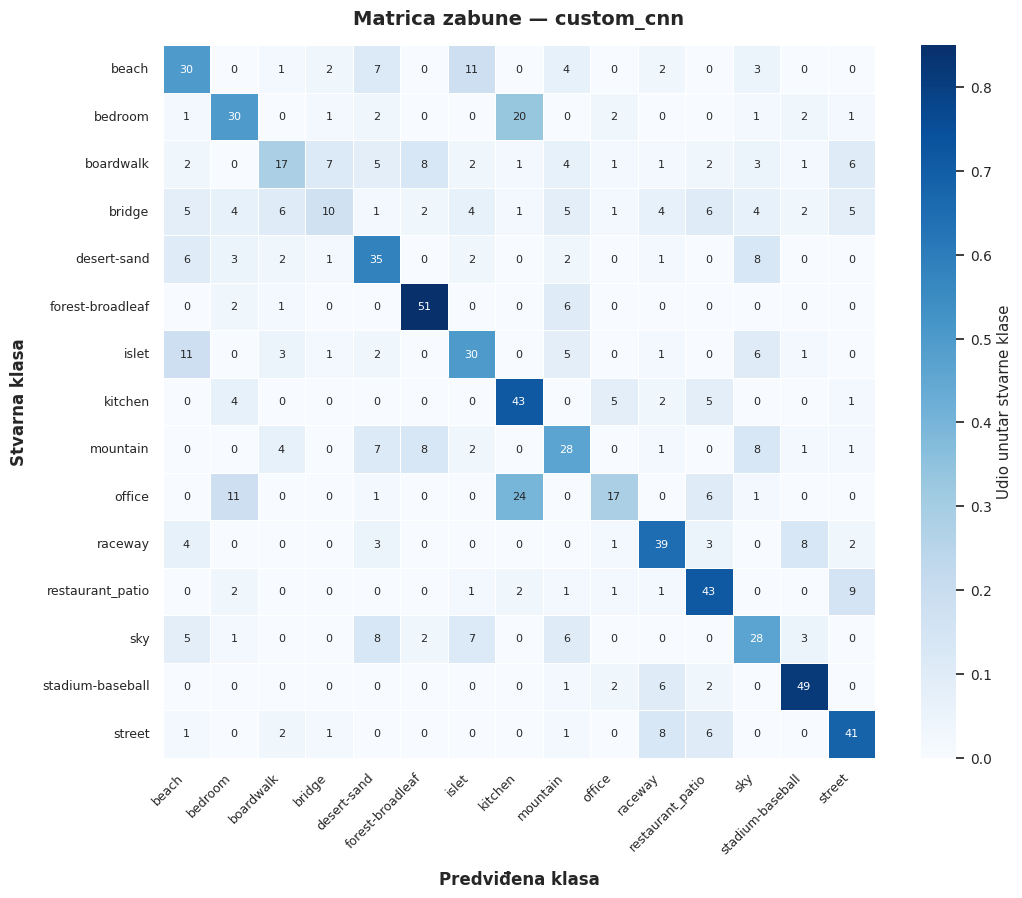

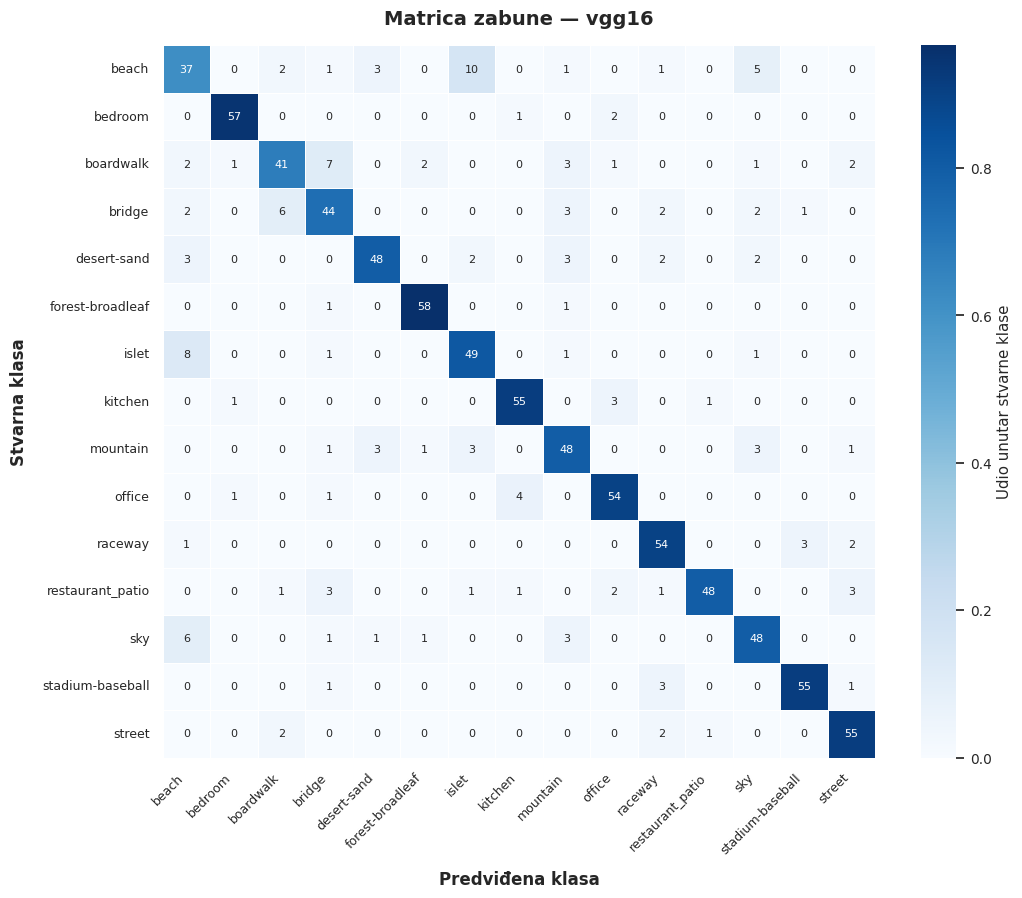

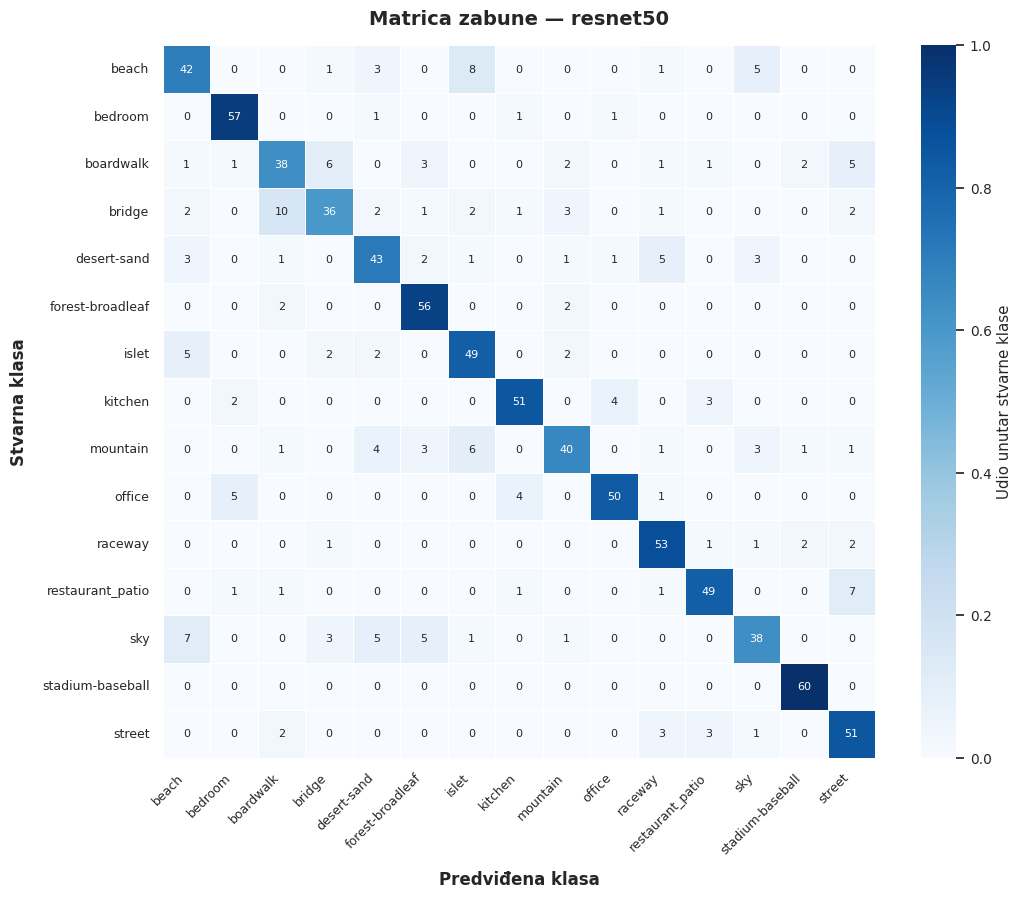

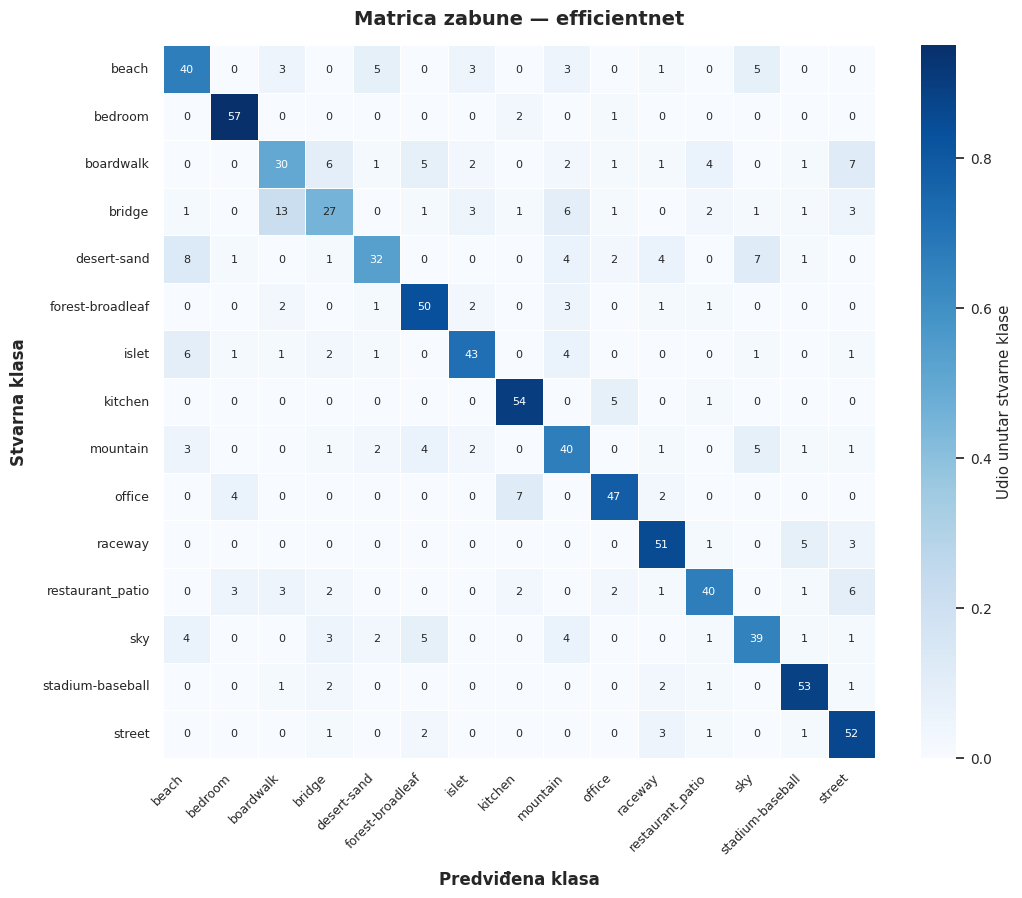

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confusion_matrix(cm, class_names, model_name, save_dir):
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(11, 9))

    sns.heatmap(
        cm_norm,
        annot=cm,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': 'Udio unutar stvarne klase'},
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 8},
        square=True,
        ax=ax
    )

    ax.set_xlabel('Predviđena klasa', fontsize=12, fontweight='bold', labelpad=10)
    ax.set_ylabel('Stvarna klasa', fontsize=12, fontweight='bold', labelpad=10)
    ax.set_title(f'Matrica zabune — {model_name}', fontsize=14, fontweight='bold', pad=15)

    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['save_dir'], f'confusion_matrix_{model_name}.png'),
                dpi=200, bbox_inches='tight')
    plt.show()

for name, res in results.items():
    plot_confusion_matrix(res['confusion_matrix'], class_names, name, CONFIG['save_dir'])

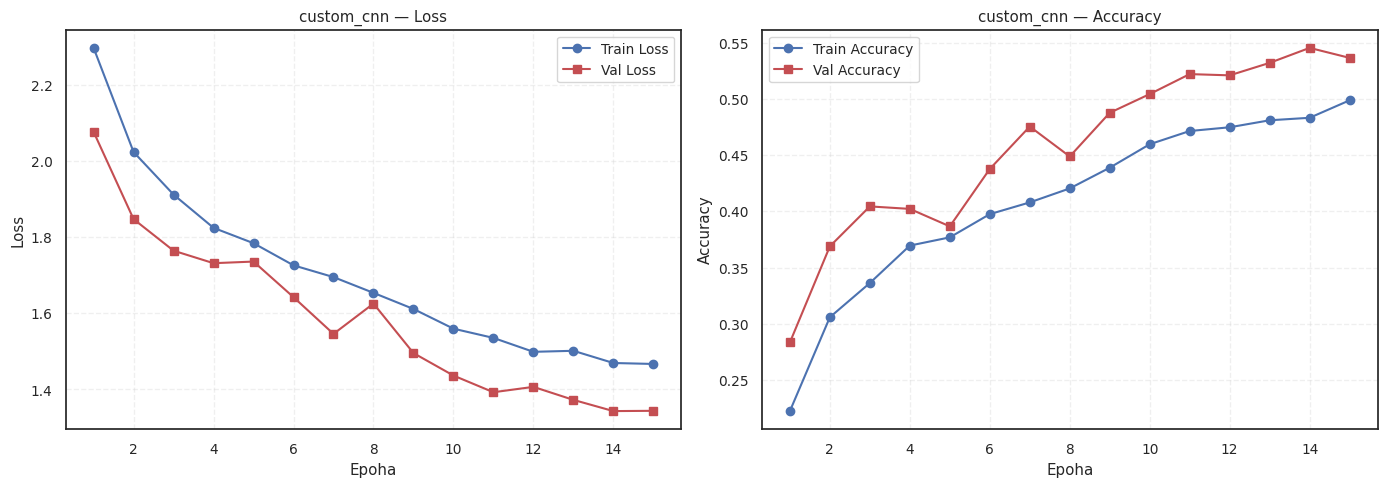

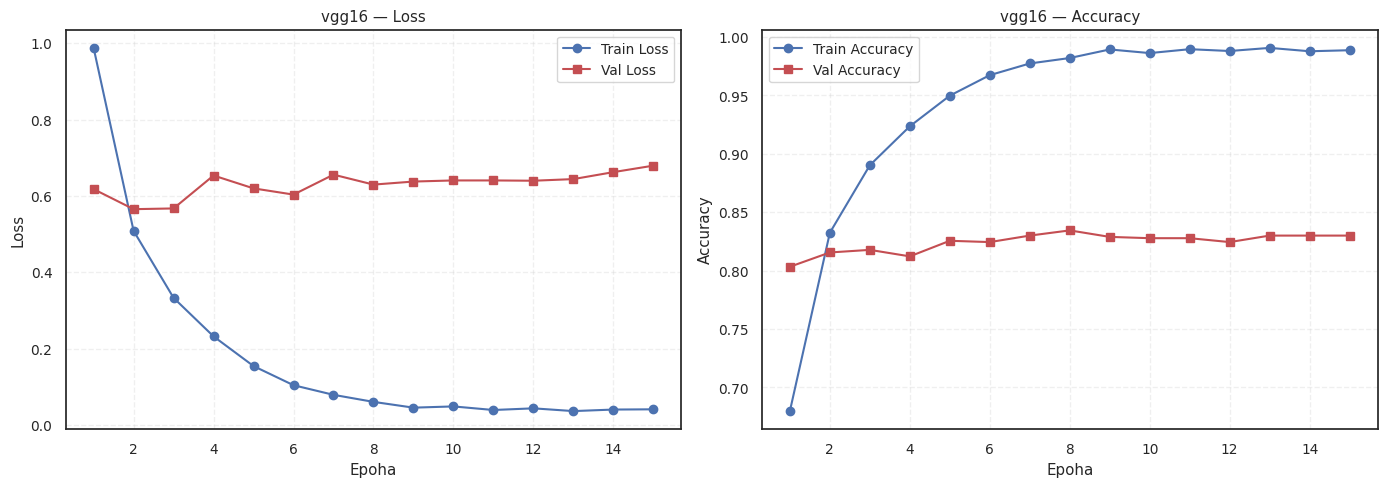

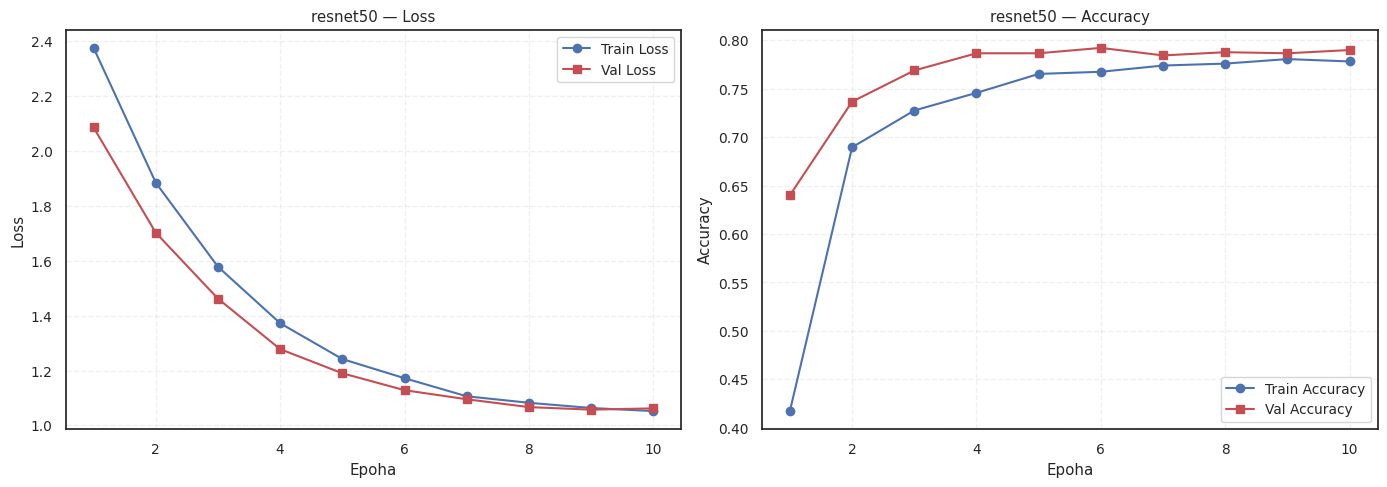

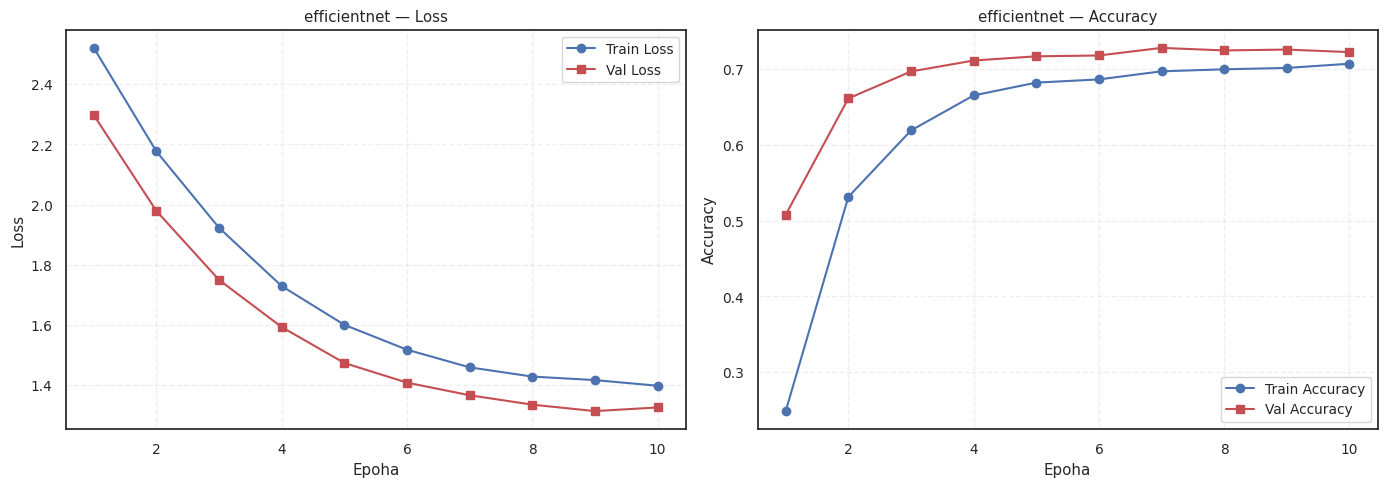

In [ ]:
histories = {
    'custom_cnn': custom_history,
    'vgg16': vgg16_history,
    'resnet50': resnet_history,
    'efficientnet': efficientnet_history,
}

def plot_learning_curves(history, model_name, save_dir):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], 'r-s', label='Val Loss')
    axes[0].set_xlabel('Epoha'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{model_name} — Loss'); axes[0].legend(); axes[0].grid(alpha=0.3, linestyle='--')

    axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train Accuracy')
    axes[1].plot(epochs, history['val_acc'], 'r-s', label='Val Accuracy')
    axes[1].set_xlabel('Epoha'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{model_name} — Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f'learning_curves_{model_name}.png'), dpi=200, bbox_inches='tight')
    plt.show()

for name, hist in histories.items():
    plot_learning_curves(hist, name, CONFIG['save_dir'])

,model,accuracy,f1_macro,f1_weighted,best_val_acc_during_training
1,vgg16,0.834444,0.834051,0.834051,0.834444
2,resnet50,0.792222,0.789137,0.789137,0.792222
3,efficientnet,0.727778,0.722345,0.722345,0.727778
0,custom_cnn,0.554444,0.540686,0.540686,0.554444


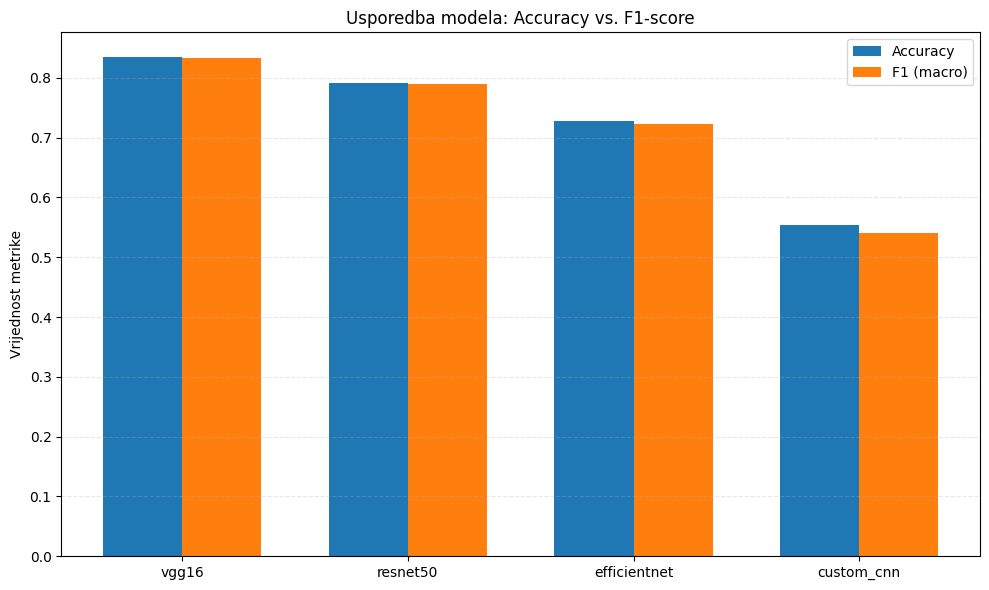

In [ ]:
import numpy as np
import pandas as pd

comparison_rows = []
for name, res in results.items():
    comparison_rows.append({
        'model': name,
        'accuracy': res['accuracy'],
        'f1_macro': res['f1_macro'],
        'f1_weighted': res['f1_weighted'],
        'best_val_acc_during_training': max(histories[name]['val_acc']),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('accuracy', ascending=False)
display(comparison_df)

x = np.arange(len(comparison_df))
width = 0.35
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, comparison_df['accuracy'], width, label='Accuracy')
plt.bar(x + width/2, comparison_df['f1_macro'], width, label='F1 (macro)')
plt.xticks(x, comparison_df['model'])
plt.ylabel('Vrijednost metrike')
plt.title('Usporedba modela: Accuracy vs. F1-score')
plt.legend(); plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['save_dir'], 'model_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()